In [3]:
!pip install numpy pandas matplotlib scikit-learn wfdb torch torchvision


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [266]:
import numpy as np
import pandas as pd
import wfdb
import torch
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [268]:
import pandas as pd
df = pd.read_csv("ptbxl.3/ptbxl_database.csv")
df.head()


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [270]:
scp = pd.read_csv("ptbxl.3/scp_statements.csv")
scp.head()

,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [272]:
df.iloc[0]['scp_codes']

"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}"

In [274]:
import ast

df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

In [275]:
type(df.iloc[0]['scp_codes'])

dict

In [278]:
df.iloc[0]['scp_codes'].keys()

dict_keys(['NORM', 'LVOLT', 'SR'])

In [280]:
scp = pd.read_csv("ptbxl.3/scp_statements.csv", index_col=0)
scp = scp[scp['diagnostic'] == 1]

id_to_diag = scp['diagnostic_class'].to_dict()

In [282]:
list(id_to_diag.keys())[:10]

['NDT', 'NST_', 'DIG', 'LNGQT', 'NORM', 'IMI', 'ASMI', 'LVH', 'LAFB', 'ISC_']

In [284]:
def get_diagnostic_class(scp_dict):
    classes = []
    for key in scp_dict.keys():
        if key in id_to_diag:
            classes.append(id_to_diag[key])
    return list(set(classes))

df['diagnostic_class'] = df['scp_codes'].apply(get_diagnostic_class)

In [286]:
def is_mi(classes):
    return 1 if 'MI' in classes else 0

df['target'] = df['diagnostic_class'].apply(is_mi)

In [288]:
df['target'].value_counts()

target
0    16330
1     5469
Name: count, dtype: int64

In [290]:
df.iloc[0]['filename_lr']

'records100/00000/00001_lr'

In [292]:
import wfdb

sample_path = "ptbxl.3/" + df.iloc[0]['filename_lr']
signal, meta = wfdb.rdsamp(sample_path)

print(signal.shape)

(1000, 12)


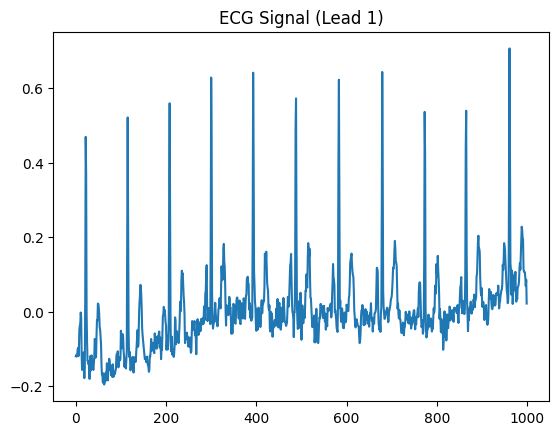

In [294]:
import matplotlib.pyplot as plt

plt.plot(signal[:, 0])  # first lead
plt.title("ECG Signal (Lead 1)")
plt.show()

In [296]:
df_sample = df.sample(3000, random_state=42)
df_sample = df_sample.reset_index(drop=True)

In [336]:
import numpy as np
import wfdb

X = []
y = []

for i in range(len(df_sample)):
    try:
        path = "ptbxl.3/" + df_sample.loc[i, 'filename_lr']
        signal, _ = wfdb.rdsamp(path)
        
        X.append(signal)
        y.append(df_sample.loc[i, 'target'])
    except Exception as e:
        print(f"Error at index {i}: {e}")

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Error at index 2055: [Errno 2] No such file or directory: 'C:/Users/polag/OneDrive/AKSHITHA/Projects/MAJOR PROJECT/ptbxl.3/records100/21000/21828_lr.hea'
Error at index 2661: [Errno 2] No such file or directory: 'C:/Users/polag/OneDrive/AKSHITHA/Projects/MAJOR PROJECT/ptbxl.3/records100/21000/21830_lr.hea'
X shape: (2998, 1000, 12)
y shape: (2998,)


In [338]:
X[0].shape

(1000, 12)

In [340]:
y[0]

0

In [342]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2398, 1000, 12)
Test shape: (600, 1000, 12)


In [344]:
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_test = (X_test - np.mean(X_test)) / np.std(X_test)

In [345]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [346]:
X_train = X_train.permute(0, 2, 1)
X_test = X_test.permute(0, 2, 1)

print("New shape:", X_train.shape)

New shape: torch.Size([2398, 12, 1000])


In [347]:
import torch.nn as nn
import torch.nn.functional as F

class ECG_CNN(nn.Module):
    def __init__(self):
        super(ECG_CNN, self).__init__()
        
        # Conv Layer 1
        self.conv1 = nn.Conv1d(in_channels=12, out_channels=32, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        
        # Conv Layer 2
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(2)
        
        # Conv Layer 3
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5)
        self.pool3 = nn.MaxPool1d(2)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 121, 64)  # calculated size
        self.fc2 = nn.Linear(64, 2)  # 2 classes (MI / Non-MI)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        x = x.view(x.size(0), -1)  # flatten
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [348]:
model = ECG_CNN()
print(model)

ECG_CNN(
  (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,))
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=15488, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


In [354]:
sample_out = model(X_train[:1])
print(sample_out.shape)

torch.Size([1, 2])


In [356]:
criterion = nn.CrossEntropyLoss()

In [358]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [360]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = model.to(device)

cpu


In [362]:
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

In [364]:
epochs = 5

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/5, Loss: 0.6377
Epoch 2/5, Loss: 0.7974
Epoch 3/5, Loss: 0.5543
Epoch 4/5, Loss: 0.5793
Epoch 5/5, Loss: 0.5947


In [365]:
model.eval()

ECG_CNN(
  (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,))
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=15488, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [366]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

In [367]:
correct = (predicted == y_test).sum().item()
total = y_test.size(0)

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.7633333333333333


In [368]:
print(predicted[:10])
print(y_test[:10])

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 1, 0, 1, 0, 0, 1, 1, 0])


In [369]:
from sklearn.metrics import confusion_matrix

In [370]:
cm = confusion_matrix(y_test.cpu(), predicted.cpu())
print(cm)

[[458   0]
 [142   0]]


In [371]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 458
False Positives: 0
False Negatives: 142
True Positives: 0


In [372]:
import numpy as np

class_counts = np.bincount(y_train.cpu().numpy())
print(class_counts)

[1832  566]


In [373]:
class_weights = torch.tensor([0.3, 0.7]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [374]:
epochs = 5

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6789
Epoch 2, Loss: 0.6777
Epoch 3, Loss: 0.6762
Epoch 4, Loss: 0.6744
Epoch 5, Loss: 0.6725


In [375]:
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

In [376]:
correct = (predicted == y_test).sum().item()
total = y_test.size(0)

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.7633333333333333


In [377]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test.cpu(), predicted.cpu())
print(cm)

[[458   0]
 [142   0]]


In [378]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 458
False Positives: 0
False Negatives: 142
True Positives: 0


In [379]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [380]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [381]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 46.6502
Epoch 2, Loss: 42.3469
Epoch 3, Loss: 39.4569
Epoch 4, Loss: 36.4383
Epoch 5, Loss: 33.3380
Epoch 6, Loss: 27.7364
Epoch 7, Loss: 25.7040
Epoch 8, Loss: 22.7108
Epoch 9, Loss: 18.1432
Epoch 10, Loss: 15.3693
Epoch 11, Loss: 13.2581
Epoch 12, Loss: 11.9197
Epoch 13, Loss: 9.9096
Epoch 14, Loss: 8.9437
Epoch 15, Loss: 8.0703
Epoch 16, Loss: 7.3489
Epoch 17, Loss: 6.7448
Epoch 18, Loss: 6.0906
Epoch 19, Loss: 5.7076
Epoch 20, Loss: 5.3420


In [382]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        outputs = model(batch_X)
        
        probs = torch.softmax(outputs, dim=1)
        predicted = (probs[:, 1] > 0.3).int()   # ← changed threshold
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

In [383]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
print("Accuracy:", accuracy)

Accuracy: 0.81


In [384]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[394  64]
 [ 50  92]]


In [385]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 394
False Positives: 64
False Negatives: 50
True Positives: 92


In [386]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       458
           1       0.59      0.65      0.62       142

    accuracy                           0.81       600
   macro avg       0.74      0.75      0.75       600
weighted avg       0.82      0.81      0.81       600

